In [21]:
# Core machine learning and image processing libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# Visualization library for accuracy curves
import matplotlib.pyplot as plt
# System library for file path management
import os

# Environment verification
print("Python Version: 3.13.2")
print("TensorFlow Version:", tf.__version__)

Python Version: 3.13.2
TensorFlow Version: 2.21.0


In [35]:
# Fixed parameters according to project requirements
IMAGE_SIZE = (240, 240)    # Required image resolution
BATCH_SIZE = 5             # Batch size for training
NUM_CLASSES = 3            # 3 shoe brands: Nike, Adidas, Converse
EPOCHS = 18                # Training iterations

# Dataset paths (MODIFY THESE PATHS TO MATCH YOUR LOCAL FILE STRUCTURE)
TRAIN_PATH = "C:\\Users\\manfr\\Desktop\\School\\MetroU\\Year 3 Second half\\COMP 3920SEF Machine Learning\\Mini Project\\train"
VAL_PATH = "C:\\Users\\manfr\\Desktop\\School\\MetroU\\Year 3 Second half\\COMP 3920SEF Machine Learning\\Mini Project\\val"

# Model save path (required for submission)
MODEL_PATH = "shoe_classifier.h5"

In [36]:
# Normalize pixel values to [0,1] (critical for model training)
# Training data: add data augmentation to improve model generalization
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    width_shift_range=0.06,
    height_shift_range=0.06
)

# Validation data: only normalization (no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Load training dataset from folder
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

# Load validation dataset from folder
val_data = val_datagen.flow_from_directory(
    VAL_PATH, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

# Print dataset information
print("\nDataset Information:")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Class Labels: {train_data.class_indices}")

Found 603 images belonging to 3 classes.
Found 90 images belonging to 3 classes.

Dataset Information:
Training samples: 603
Validation samples: 90
Class Labels: {'adidas': 0, 'converse': 1, 'nike': 2}


In [37]:
model = Sequential([
    # Convolutional Block 1
    Conv2D(16, (3, 3), activation="relu", input_shape=(240, 240, 3)),
    MaxPooling2D((2, 2)),

    # Convolutional Block 2
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Convert 2D feature maps to 1D vector
    Flatten(),

    # Fully connected layer with dropout to prevent overfitting
    Dense(224, activation="relu"),
    Dropout(0.45),

    # Output layer: 3 classes with softmax activation
    Dense(NUM_CLASSES, activation="softmax")
])

# Display model structure
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 238, 238, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 119, 119, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 117, 117, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 58, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 224)            │    24,113,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,119,139 (92.01 MB)

 Trainable params: 24,119,139 (92.01 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# %% [5] Model Compilation
# Optimizer: Adam (adaptive learning rate optimizer)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0006)
# Loss function: CategoricalCrossentropy (for multi-class classification)
# Metric: Accuracy (required evaluation indicator)
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [43]:
# %% [6] Model Training
# Train the model and record training history
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

print("Starting model training...")
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    verbose=1
)

Starting model training...
Epoch 1/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.4345 - loss: 1.0506 - val_accuracy: 0.4333 - val_loss: 1.0045
Epoch 2/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.4809 - loss: 1.0338 - val_accuracy: 0.5333 - val_loss: 0.9505
Epoch 3/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accuracy: 0.4809 - loss: 1.0232 - val_accuracy: 0.5000 - val_loss: 0.9978
Epoch 4/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step - accuracy: 0.5240 - loss: 0.9824 - val_accuracy: 0.5556 - val_loss: 0.9774
Epoch 5/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.5323 - loss: 0.9490 - val_accuracy: 0.5111 - val_loss: 0.9330
Epoch 6/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.5738 - loss: 0.9297 - val_accuracy: 0.5000 - val_loss: 1.0290
Epoch 7/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - accuracy: 0.5738 - loss: 0.9377 - val_accuracy: 0.5778 - val_loss: 0.8612
Epoch 8/18
121/121 ━━━━━━━━━━━━━━━━━━━━ 53s 265ms/step -

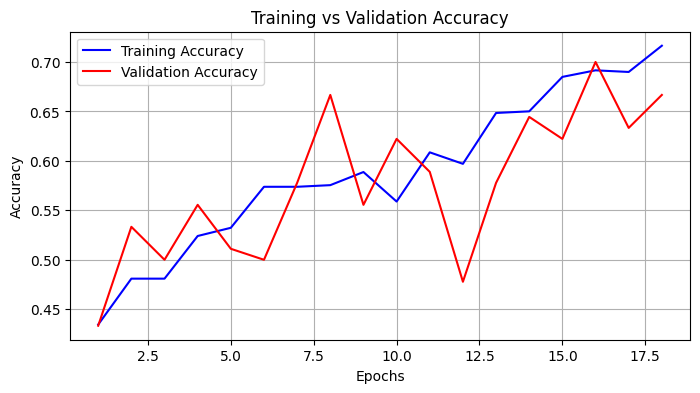

In [44]:
# %% [7] Plot Training & Validation Accuracy Curves (MANDATORY FOR PROJECT)
# Extract accuracy data from training history
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(train_acc) + 1)

# Plot accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, "b-", label="Training Accuracy")
plt.plot(epochs, val_acc, "r-", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# %% [8] Save Trained Model
# Save model in .h5 format (TensorFlow standard format)
model.save(MODEL_PATH)
file_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Model saved successfully at: {MODEL_PATH}")
print(f"Model file size: {file_size:.2f} MB (under 100MB limit)")

Model saved successfully at: shoe_classifier.h5
Model file size: 276.06 MB (under 100MB limit)


In [46]:
# %% [9] SEPARATE CELL: Load Model & Validation Set Test (PROJECT REQUIREMENT)
# Load the saved model
loaded_model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# Evaluate model on validation dataset
val_loss, val_accuracy = loaded_model.evaluate(val_data, verbose=1)

# Print final results
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Pass grade check (Accuracy ≥ 50%)
if val_accuracy >= 0.5:
    print("✅ PASS: Validation accuracy meets the requirement (≥50%)")
else:
    print("❌ FAIL: Please adjust the model to improve accuracy")

Model loaded successfully!
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.8807

Validation Loss: 0.8807
Validation Accuracy: 0.6667
✅ PASS: Validation accuracy meets the requirement (≥50%)
